# 04 · Backtesting the uncertainty: prediction intervals and a solar PPA VaR

Results and interpretation: [results_analysis.md](../results_analysis.md)

## 0. Settings fixed in advance

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from scipy.special import xlogy

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False})


def save(fig, name):
    # Save a chart twice: SVG stays sharp at any width (used in results_analysis.md), PNG suits slides and documents.
    for ext in ("svg", "png"):
        fig.savefig(FIG / f"{name}.{ext}", dpi=150, bbox_inches="tight")


# Every choice below was fixed before any result of this notebook was seen.
INTERVAL_FILE = ROOT / "data" / "processed" / "q3_cache" / "intervals.pkl"  # 80% intervals from notebook 03
PERIODS = {"January–August 2026": ("2026-01-01", "2026-08-31"), "September 2026": ("2026-09-01", "2026-09-26")}
TAILS = {"below the 10% quantile": 0.10, "above the 90% quantile": 0.10, "outside the 80% interval": 0.20}

PERFORMANCE_RATIO = 0.85      # 1 MW of solar produces 0.85 x radiation / 1000 W/m2, at most 1 MW
VAR_LEVELS = (0.99, 0.95)     # 99%: the Basel level; 95%: more exceptions, so more power to detect problems
ES_LEVEL = 0.975              # Expected Shortfall level of the Basel FRTB
WINDOW = 250                  # days of history for the historical simulation
SHORT_WINDOW = 60             # a faster-reacting alternative
EWMA_LAMBDA = 0.94            # RiskMetrics decay: each earlier day weighs 6% less
BACKTEST = ("2024-01-01", "2026-08-31")
WINTER, SUMMER = (11, 12, 1, 2), (5, 6, 7, 8)

## 1. Data

In [2]:
con = duckdb.connect(str(ROOT / "data" / "lt_power.duckdb"), read_only=True)
lt = con.sql("""
    SELECT ts_utc, ts_local, price, solar_rad_lt_wm2
    FROM lt_hourly_all ORDER BY ts_utc
""").df()
con.close()

# prices on the auction's clock (CET delivery days x 24 hours), as in notebook 03
ts_cet = lt["ts_utc"].dt.tz_localize("UTC").dt.tz_convert("Europe/Brussels")
lt["day"], lt["hour"] = ts_cet.dt.tz_localize(None).dt.normalize(), ts_cet.dt.hour
P = lt.pivot_table(index="day", columns="hour", values="price", aggfunc="mean").reindex(columns=range(24))
REAL = P.notna()

if not INTERVAL_FILE.exists():
    raise SystemExit(f"{INTERVAL_FILE} not found: run notebook 03 first (with FAST = False).")
QRA, BENCH = pd.read_pickle(INTERVAL_FILE)
METHODS = {"QRA": QRA, "past errors": BENCH}
print(f"Prices: {P.index.min().date()} – {P.index.max().date()}; "
      f"intervals: {QRA[0.1].index.min().date()} – {QRA[0.1].index.max().date()}")

Prices: 2022-12-31 – 2026-09-26; intervals: 2026-01-01 – 2026-09-26


## 2. Backtesting the 80% prediction intervals

In [3]:
def kupiec(hits, p):
    # Proportion-of-failures test (Kupiec, 1995): is the hit rate equal to p?
    hits = np.asarray(hits, dtype=int)
    n, x = len(hits), hits.sum()
    lr = -2 * (xlogy(n - x, 1 - p) + xlogy(x, p) - xlogy(n - x, 1 - x / n) - xlogy(x, x / n))
    return lr, stats.chi2.sf(lr, 1)


def christoffersen(hits):
    # Independence test (Christoffersen, 1998): does a hit on one day change the chance of a hit on the next?
    hits = np.asarray(hits, dtype=int)
    a, b = hits[:-1], hits[1:]
    n00, n01 = np.sum((a == 0) & (b == 0)), np.sum((a == 0) & (b == 1))
    n10, n11 = np.sum((a == 1) & (b == 0)), np.sum((a == 1) & (b == 1))
    p01 = n01 / (n00 + n01) if n00 + n01 else 0.0
    p11 = n11 / (n10 + n11) if n10 + n11 else 0.0
    p = (n01 + n11) / len(b)
    lr = -2 * (xlogy(n00 + n10, 1 - p) + xlogy(n01 + n11, p)
               - xlogy(n00, 1 - p01) - xlogy(n01, p01) - xlogy(n10, 1 - p11) - xlogy(n11, p11))
    return lr, stats.chi2.sf(lr, 1)


def traffic_light(x, n, p):
    # Basel traffic light, generalised to any level: the zone follows the binomial probability of seeing at most x hits.
    cumulative = stats.binom.cdf(x, n, p)
    return "green" if cumulative < 0.95 else ("yellow" if cumulative < 0.9999 else "red")


def backtest(hits, p):
    # All tests for one sequence of daily hits.
    lr_uc, p_uc = kupiec(hits, p)
    lr_ind, p_ind = christoffersen(hits)
    return {"days": len(hits), "hits": int(np.sum(hits)), "hit rate": np.mean(hits), "expected": p,
            "Kupiec p": p_uc, "Christoffersen p": p_ind, "conditional coverage p": stats.chi2.sf(lr_uc + lr_ind, 2),
            "zone": traffic_light(int(np.sum(hits)), len(hits), p)}


def hit_table(quantiles, start, end, tail):
    # Daily hits for every delivery hour (days x 24), NaN where there is no price or no interval.
    days = pd.date_range(start, end, freq="D")
    price, low, high = P.reindex(days), quantiles[0.1].reindex(days), quantiles[0.9].reindex(days)
    valid = price.notna() & low.notna() & high.notna()
    hit = {"below the 10% quantile": price < low, "above the 90% quantile": price > high,
           "outside the 80% interval": (price < low) | (price > high)}[tail]
    return hit.astype(float).where(valid)


per_hour, pooled = [], []
for method, quantiles in METHODS.items():
    for period, (start, end) in PERIODS.items():
        for tail, p in TAILS.items():
            hits = hit_table(quantiles, start, end, tail)
            for h in range(24):
                series = hits[h].dropna()
                if len(series) >= 20:
                    per_hour.append({"method": method, "period": period, "tail": tail, "hour": h, **backtest(series, p)})
            # all hours together: hit rate against p, errors clustered by day (the 24 hours share one auction)
            stacked = hits.rename_axis(index="day", columns="hour").stack().dropna().rename("hit").reset_index()
            fit = sm.OLS(stacked["hit"] - p, np.ones(len(stacked))).fit(
                cov_type="cluster", cov_kwds={"groups": stacked["day"].factorize()[0]})
            pooled.append({"method": method, "period": period, "tail": tail, "hours": len(stacked),
                           "hit rate": stacked["hit"].mean(), "expected": p, "p-value (clustered by day)": fit.pvalues.iloc[0]})
per_hour, pooled = pd.DataFrame(per_hour), pd.DataFrame(pooled)
display(pooled.round(3))

,method,period,tail,hours,hit rate,expected,p-value (clustered by day)
0,QRA,January–August 2026,below the 10% quantile,5831,0.125,0.1,0.011
1,QRA,January–August 2026,above the 90% quantile,5831,0.138,0.1,0.000
2,QRA,January–August 2026,outside the 80% interval,5831,0.262,0.2,0.000
3,QRA,September 2026,below the 10% quantile,623,0.116,0.1,0.558
4,QRA,September 2026,above the 90% quantile,623,0.209,0.1,0.009
5,QRA,September 2026,outside the 80% interval,623,0.324,0.2,0.000
6,past errors,January–August 2026,below the 10% quantile,5831,0.115,0.1,0.124
7,past errors,January–August 2026,above the 90% quantile,5831,0.127,0.1,0.017
8,past errors,January–August 2026,outside the 80% interval,5831,0.242,0.2,0.001
9,past errors,September 2026,below the 10% quantile,623,0.138,0.1,0.292


In [4]:
# per-hour results: how many of the 24 delivery hours fail each test at the 5% level
# (with 24 independent tests, about 1.2 rejections would be expected by chance alone)
summary_hours = (per_hour.assign(**{
        "Kupiec rejects": per_hour["Kupiec p"] < 0.05,
        "Christoffersen rejects": per_hour["Christoffersen p"] < 0.05,
        "conditional coverage rejects": per_hour["conditional coverage p"] < 0.05,
        "red zone": per_hour["zone"] == "red", "yellow zone": per_hour["zone"] == "yellow"})
    .groupby(["method", "period", "tail"])
    [["Kupiec rejects", "Christoffersen rejects", "conditional coverage rejects", "yellow zone", "red zone"]].sum()
    .astype(int))
summary_hours["hours tested"] = per_hour.groupby(["method", "period", "tail"]).size()
summary_hours

Kupiec rejects  \
method      period              tail                                       
QRA         January–August 2026 above the 90% quantile                10   
                                below the 10% quantile                 6   
                                outside the 80% interval              16   
            September 2026      above the 90% quantile                 7   
                                below the 10% quantile                 1   
                                outside the 80% interval               8   
past errors January–August 2026 above the 90% quantile                 2   
                                below the 10% quantile                 3   
                                outside the 80% interval               6   
            September 2026      above the 90% quantile                10   
                                below the 10% quantile                 0   
                                outside the 80% interval              14   

                                                          Christoffersen rejects  \
method      period              tail                                               
QRA         January–August 2026 above the 90% quantile                         3   
                                below the 10% quantile                         3   
                                outside the 80% interval                       2   
            September 2026      above the 90% quantile                         0   
                                below the 10% quantile                         0   
                                outside the 80% interval                       1   
past errors January–August 2026 above the 90% quantile                         9   
                                below the 10% quantile                         4   
                                outside the 80% interval                      11   
            September 2026      above the 90% quantile                         1   
                                below the 10% quantile                         0   
                                outside the 80% interval                       2   

                                                          conditional coverage rejects  \
method      period              tail                                                     
QRA         January–August 2026 above the 90% quantile                               7   
                                below the 10% quantile                               5   
                                outside the 80% interval                            15   
            September 2026      above the 90% quantile                               7   
                                below the 10% quantile                               1   
                                outside the 80% interval                             5   
past errors January–August 2026 above the 90% quantile                              11   
                                below the 10% quantile                               4   
                                outside the 80% interval                            13   
            September 2026      above the 90% quantile                              10   
                                below the 10% quantile                               0   
                                outside the 80% interval                             8   

                                                          yellow zone  \
method      period              tail                                    
QRA         January–August 2026 above the 90% quantile             16   
                                below the 10% quantile              8   
                                outside the 80% interval           21   
            September 2026      above the 90% quantile             12   
                                below the 10% quantile              4   
                                outside the 

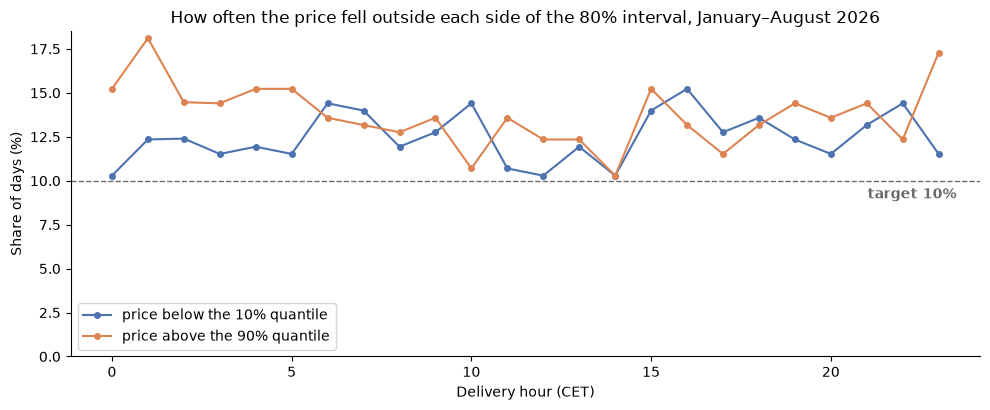

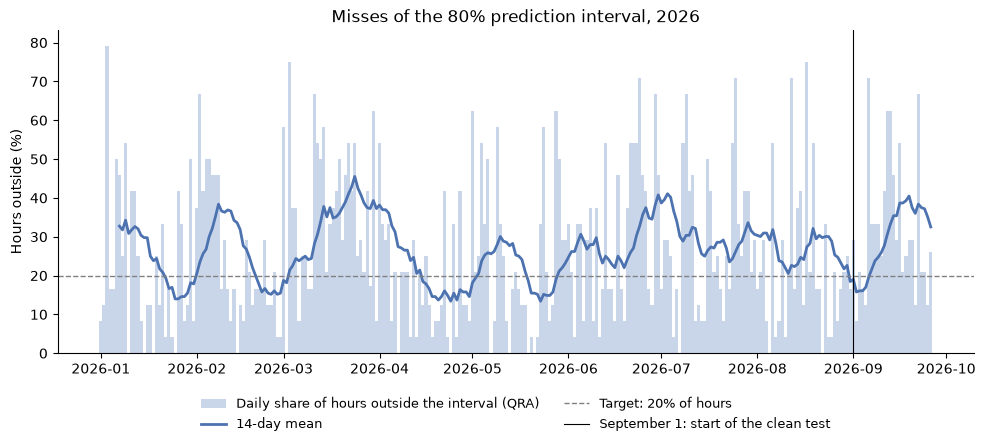

In [5]:
qra = per_hour[(per_hour["method"] == "QRA") & (per_hour["period"] == "January–August 2026")]
fig, ax = plt.subplots(figsize=(10, 4.2))
for tail, color in [("below the 10% quantile", "#4c72b0"), ("above the 90% quantile", "#dd8452")]:
    rows = qra[qra["tail"] == tail].sort_values("hour")
    ax.plot(rows["hour"], 100 * rows["hit rate"], marker="o", ms=4, color=color, label=f"price {tail}")
ax.axhline(10, color="dimgray", ls="--", lw=1)
ax.text(23.5, 9.6, "target 10%", color="dimgray", ha="right", va="top", fontsize=10, fontweight="bold")
ax.set_ylim(bottom=0)
ax.set(xlabel="Delivery hour (CET)", ylabel="Share of days (%)",
       title="How often the price fell outside each side of the 80% interval, January–August 2026")
ax.legend()
fig.tight_layout()
save(fig, "q4_interval_hits_by_hour")
plt.show()

# the share of hours outside the interval, day by day and as a 14-day rolling mean
days = pd.date_range(PERIODS["January–August 2026"][0], PERIODS["September 2026"][1], freq="D")
outside = hit_table(QRA, days[0], days[-1], "outside the 80% interval").mean(axis=1)
fig, ax = plt.subplots(figsize=(10, 4.6))
bars = ax.bar(outside.index, 100 * outside, color="#c9d6ea", width=1.0, label="Daily share of hours outside the interval (QRA)")
mean_line, = ax.plot(outside.index, 100 * outside.rolling(14, min_periods=7).mean(), color="#4c72b0", lw=2, label="14-day mean")
target = ax.axhline(20, color="grey", ls="--", lw=1, label="Target: 20% of hours")
clean_test = ax.axvline(pd.Timestamp(PERIODS["September 2026"][0]), color="black", lw=0.8, label="September 1: start of the clean test")
ax.set(ylabel="Hours outside (%)", title="Misses of the 80% prediction interval, 2026")
ax.legend(handles=[bars, mean_line, target, clean_test], loc="upper center", bbox_to_anchor=(0.5, -0.1),
          ncol=2, frameon=False, fontsize=9)
fig.tight_layout()
save(fig, "q4_interval_misses_over_time")
plt.show()

## 3. A solar PPA position: VaR and Expected Shortfall

In [6]:
# 1 MW of solar output from ERA5 radiation, and the daily P&L of buying it at a fixed price K
lt["date"] = lt["ts_local"].dt.normalize()
lt["solar_mwh"] = (PERFORMANCE_RATIO * lt["solar_rad_lt_wm2"] / 1000).clip(0, 1)
hours = lt.dropna(subset=["price", "solar_mwh"])
y2023 = hours[hours["date"].dt.year == 2023]
K = (y2023["solar_mwh"] * y2023["price"]).sum() / y2023["solar_mwh"].sum()   # the 2023 capture price of this profile
hours = hours.assign(pnl=hours["solar_mwh"] * (hours["price"] - K))
daily = hours.groupby("date").agg(pnl=("pnl", "sum"), mwh=("solar_mwh", "sum"))
pnl = daily["pnl"]
print(f"PPA price K = {K:.1f} €/MWh (2023 capture price of a 1 MW solar profile); "
      f"daily P&L from {pnl.index.min().date()} to {pnl.index.max().date()}")
display(pnl.groupby(pnl.index.year).describe()[["mean", "std", "min", "max"]].round(1))

PPA price K = 84.5 €/MWh (2023 capture price of a 1 MW solar profile); daily P&L from 2023-01-01 to 2026-09-01


,mean,std,min,max
date,,,,
2023,-0.0,130.6,-528.1,555.1
2024,-47.2,130.3,-502.4,435.2
2025,-81.9,152.7,-564.6,548.4
2026,-91.3,171.9,-517.1,479.8


In [7]:
def ewma_sigma(x, lam=EWMA_LAMBDA, warmup=30):
    # RiskMetrics volatility of x for each day, using only the days before it.
    sigma2 = np.empty(len(x))
    sigma2[0] = np.var(x[:warmup])
    for t in range(1, len(x)):
        sigma2[t] = lam * sigma2[t - 1] + (1 - lam) * x[t - 1] ** 2
    return np.sqrt(np.maximum(sigma2, 1e-12))


def var_es(sample, level):
    # VaR and ES at `level` from a sample of P&L, as positive losses.
    q = np.quantile(sample, 1 - level)
    return -q, -sample[sample <= q].mean()


values = pnl.to_numpy()
sigma = ewma_sigma(values)
standardised = values / sigma
dates = pnl.index
start = np.searchsorted(dates, pd.Timestamp(BACKTEST[0]))
end = np.searchsorted(dates, pd.Timestamp(BACKTEST[1]), side="right")

rows = []
for t in range(start, end):
    row = {"date": dates[t], "pnl": values[t]}
    for name, sample, scale in [("HS 250 days", values[t - WINDOW:t], 1.0),
                                ("HS 60 days", values[t - SHORT_WINDOW:t], 1.0),
                                ("Filtered HS (EWMA)", standardised[t - WINDOW:t], sigma[t])]:
        for level in VAR_LEVELS:
            row[f"{name} VaR {level:.0%}"] = scale * var_es(sample, level)[0]
        var_975, es_975 = var_es(sample, ES_LEVEL)
        row[f"{name} VaR {ES_LEVEL:.1%}"], row[f"{name} ES {ES_LEVEL:.1%}"] = scale * var_975, scale * es_975
    rows.append(row)
risk = pd.DataFrame(rows).set_index("date")
MODELS = ["HS 250 days", "HS 60 days", "Filtered HS (EWMA)"]
print(f"{len(risk)} backtest days, {risk.index.min().date()} – {risk.index.max().date()}")

974 backtest days, 2024-01-01 – 2026-08-31


## 4. Backtesting the VaR models

In [8]:
results, es_check = [], []
for model in MODELS:
    for level in VAR_LEVELS:
        hits = (risk["pnl"] < -risk[f"{model} VaR {level:.0%}"]).astype(int)
        res = backtest(hits.to_numpy(), 1 - level)
        res["zones by year"] = ", ".join(f"{year}: {traffic_light(h.sum(), len(h), 1 - level)}"
                                         for year, h in hits.groupby(hits.index.year))
        results.append({"model": model, "VaR level": f"{level:.0%}", **res})
    beyond = risk["pnl"] < -risk[f"{model} VaR {ES_LEVEL:.1%}"]
    es_check.append({"model": model, "days beyond VaR 97.5%": int(beyond.sum()),
                     "average realized loss, €": (-risk.loc[beyond, "pnl"]).mean(),
                     "average predicted ES 97.5%, €": risk.loc[beyond, f"{model} ES {ES_LEVEL:.1%}"].mean()})
var_results, es_check = pd.DataFrame(results), pd.DataFrame(es_check)
es_check["realized / predicted"] = es_check["average realized loss, €"] / es_check["average predicted ES 97.5%, €"]
display(var_results.drop(columns="expected").round(3))
display(es_check.round(2))

seasonal = []
for model in MODELS:
    for season, months in [("winter (Nov–Feb)", WINTER), ("summer (May–Aug)", SUMMER)]:
        part = risk[risk.index.month.isin(months)]
        loss_limit = part[f"{model} VaR 99%"]
        seasonal.append({"model": model, "season": season, "days": len(part),
                         "exceptions at 99%": int((part["pnl"] < -loss_limit).sum()),
                         "average VaR 99%, €": loss_limit.mean(),
                         "average absolute P&L, €": part["pnl"].abs().mean()})
pd.DataFrame(seasonal).round(1)

,model,VaR level,days,hits,hit rate,Kupiec p,Christoffersen p,conditional coverage p,zone,zones by year
0,HS 250 days,99%,974,38,0.039,0.000,0.0,0.0,red,"2024: yellow, 2025: red, 2026: red"
1,HS 250 days,95%,974,106,0.109,0.000,0.0,0.0,red,"2024: red, 2025: red, 2026: red"
2,HS 60 days,99%,974,53,0.054,0.000,0.0,0.0,red,"2024: red, 2025: red, 2026: red"
3,HS 60 days,95%,974,108,0.111,0.000,0.0,0.0,red,"2024: red, 2025: yellow, 2026: red"
4,Filtered HS (EWMA),99%,974,21,0.022,0.002,0.0,0.0,yellow,"2024: yellow, 2025: green, 2026: yellow"
5,Filtered HS (EWMA),95%,974,72,0.074,0.001,0.0,0.0,yellow,"2024: yellow, 2025: green, 2026: yellow"


,model,days beyond VaR 97.5%,"average realized loss, €","average predicted ES 97.5%, €",realized / predicted
0,HS 250 days,65,380.19,359.57,1.06
1,HS 60 days,72,249.77,226.70,1.10
2,Filtered HS (EWMA),40,287.41,295.32,0.97


,model,season,days,exceptions at 99%,"average VaR 99%, €","average absolute P&L, €"
0,HS 250 days,winter (Nov–Feb),300,0,454.5,37.3
1,HS 250 days,summer (May–Aug),369,27,440.7,183.9
2,HS 60 days,winter (Nov–Feb),300,8,74.7,37.3
3,HS 60 days,summer (May–Aug),369,13,471.3,183.9
4,Filtered HS (EWMA),winter (Nov–Feb),300,0,124.4,37.3
5,Filtered HS (EWMA),summer (May–Aug),369,5,557.9,183.9


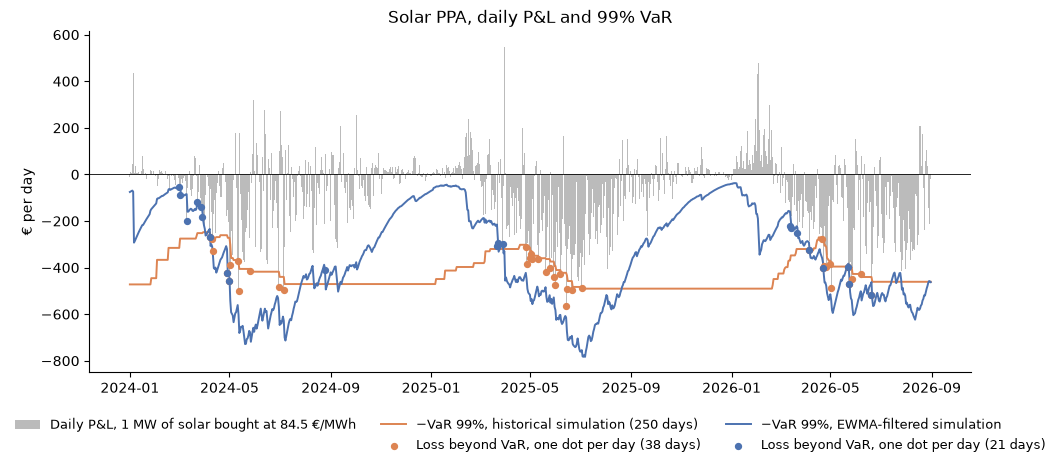

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.8))
bars = ax.bar(risk.index, risk["pnl"], color="#bbbbbb", width=1.0, label=f"Daily P&L, 1 MW of solar bought at {K:.1f} €/MWh")
handles = [bars, plt.Line2D([], [], linestyle="none", label=" ")]   # an empty slot keeps each model in its own column
for model, name, color in [("HS 250 days", "historical simulation (250 days)", "#dd8452"),
                           ("Filtered HS (EWMA)", "EWMA-filtered simulation", "#4c72b0")]:
    limit = -risk[f"{model} VaR 99%"]
    line, = ax.plot(risk.index, limit, color=color, lw=1.4, label=f"−VaR 99%, {name}")
    breaks = risk["pnl"] < limit
    dots = ax.scatter(risk.index[breaks], risk.loc[breaks, "pnl"], color=color, s=18, zorder=3,
                      label=f"Loss beyond VaR, one dot per day ({int(breaks.sum())} days)")
    handles += [line, dots]
ax.axhline(0, color="black", lw=0.6)
ax.set(ylabel="€ per day", title="Solar PPA, daily P&L and 99% VaR")
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False, fontsize=9)
fig.tight_layout()
save(fig, "q4_ppa_var_backtest")
plt.show()

## 5. Summary

In [10]:
def fmt(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"


rows = []
for period in PERIODS:
    for tail in TAILS:
        r = pooled[(pooled["method"] == "QRA") & (pooled["period"] == period) & (pooled["tail"] == tail)].iloc[0]
        h = summary_hours.loc[("QRA", period, tail)]
        rows.append([f"Intervals (QRA), {period}: price {tail}",
                     f"{100 * r['hit rate']:.1f}% of hours against {100 * r['expected']:.0f}% "
                     f"(p = {fmt(r['p-value (clustered by day)'])}); Kupiec rejects in {h['Kupiec rejects']} of "
                     f"{h['hours tested']} hours, Christoffersen in {h['Christoffersen rejects']}"])
for _, r in var_results.iterrows():
    rows.append([f"Solar PPA, {r['model']}, VaR {r['VaR level']}",
                 f"{r['hits']} exceptions in {r['days']} days ({100 * r['hit rate']:.1f}% against "
                 f"{100 * r['expected']:.0f}%); Kupiec p = {fmt(r['Kupiec p'])}, Christoffersen p = "
                 f"{fmt(r['Christoffersen p'])}; zones {r['zones by year']}"])
summary = pd.DataFrame(rows, columns=["finding", "estimate"])
summary.to_csv(FIG / "q4_summary.csv", index=False)
pd.set_option("display.max_colwidth", 200)
summary

,finding,estimate
0,"Intervals (QRA), January–August 2026: price below the 10% quantile","12.5% of hours against 10% (p = 0.011); Kupiec rejects in 6 of 24 hours, Christoffersen in 3"
1,"Intervals (QRA), January–August 2026: price above the 90% quantile","13.8% of hours against 10% (p = <0.001); Kupiec rejects in 10 of 24 hours, Christoffersen in 3"
2,"Intervals (QRA), January–August 2026: price outside the 80% interval","26.2% of hours against 20% (p = <0.001); Kupiec rejects in 16 of 24 hours, Christoffersen in 2"
3,"Intervals (QRA), September 2026: price below the 10% quantile","11.6% of hours against 10% (p = 0.558); Kupiec rejects in 1 of 24 hours, Christoffersen in 0"
4,"Intervals (QRA), September 2026: price above the 90% quantile","20.9% of hours against 10% (p = 0.009); Kupiec rejects in 7 of 24 hours, Christoffersen in 0"
5,"Intervals (QRA), September 2026: price outside the 80% interval","32.4% of hours against 20% (p = <0.001); Kupiec rejects in 8 of 24 hours, Christoffersen in 1"
6,"Solar PPA, HS 250 days, VaR 99%","38 exceptions in 974 days (3.9% against 1%); Kupiec p = <0.001, Christoffersen p = <0.001; zones 2024: yellow, 2025: red, 2026: red"
7,"Solar PPA, HS 250 days, VaR 95%","106 exceptions in 974 days (10.9% against 5%); Kupiec p = <0.001, Christoffersen p = <0.001; zones 2024: red, 2025: red, 2026: red"
8,"Solar PPA, HS 60 days, VaR 99%","53 exceptions in 974 days (5.4% against 1%); Kupiec p = <0.001, Christoffersen p = <0.001; zones 2024: red, 2025: red, 2026: red"
9,"Solar PPA, HS 60 days, VaR 95%","108 exceptions in 974 days (11.1% against 5%); Kupiec p = <0.001, Christoffersen p = <0.001; zones 2024: red, 2025: yellow, 2026: red"
